In [4]:
from google.colab import files

uploaded = files.upload()

Saving heart+disease.zip to heart+disease.zip


In [5]:
import os

print(os.listdir())

['.config', 'heart+disease.zip', 'sample_data']


In [6]:
import zipfile

with zipfile.ZipFile('heart+disease.zip', 'r') as zip_ref:
    zip_ref.extractall('heart_dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
import os

for root, dirs, files in os.walk('heart_dataset'):
    for file in files:
        print(os.path.join(root, file))

heart_dataset/Index
heart_dataset/switzerland.data
heart_dataset/bak
heart_dataset/cleve.mod
heart_dataset/WARNING
heart_dataset/ask-detrano
heart_dataset/heart-disease.names
heart_dataset/hungarian.data
heart_dataset/cleveland.data
heart_dataset/processed.hungarian.data
heart_dataset/new.data
heart_dataset/processed.switzerland.data
heart_dataset/reprocessed.hungarian.data
heart_dataset/processed.va.data
heart_dataset/long-beach-va.data
heart_dataset/processed.cleveland.data
heart_dataset/costs/Index
heart_dataset/costs/heart-disease.group
heart_dataset/costs/heart-disease.cost
heart_dataset/costs/heart-disease.delay
heart_dataset/costs/heart-disease.README
heart_dataset/costs/heart-disease.expense


In [8]:
# Import required libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

# ============================================================
# STEP 1: LOAD DATASET
# ============================================================

# Column names according to UCI Heart Disease Dataset

column_names = [
    'age',         # Age of patient
    'sex',         # Gender (1 = Male, 0 = Female)
    'cp',          # Chest pain type
    'trestbps',    # Resting blood pressure
    'chol',        # Serum cholesterol
    'fbs',         # Fasting blood sugar
    'restecg',     # Resting electrocardiographic results
    'thalach',     # Maximum heart rate achieved
    'exang',       # Exercise induced angina
    'oldpeak',     # ST depression induced by exercise
    'slope',       # Slope of peak exercise ST segment
    'ca',          # Number of major vessels
    'thal',        # Thalassemia
    'target'       # Diagnosis of heart disease
]

# Load dataset
# na_values='?' automatically converts '?' to NaN

df = pd.read_csv(
    "heart_dataset/processed.cleveland.data",
    header=None,
    names=column_names,
    na_values='?'
)

print("="*50)
print("DATASET LOADED SUCCESSFULLY")
print("="*50)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

DATASET LOADED SUCCESSFULLY

Dataset Shape:
(303, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [9]:
# STEP 2: CHECK MISSING VALUES
# ============================================================

print("\n" + "="*50)
print("MISSING VALUE ANALYSIS")
print("="*50)

print(df.isnull().sum())



MISSING VALUE ANALYSIS
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [10]:
# STEP 3: HANDLE MISSING VALUES
# ============================================================

# Fill missing values using median
# Median is preferred because it is less affected by outliers

df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

print("\nMissing Values After Imputation:")
print(df.isnull().sum())



Missing Values After Imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [11]:
# STEP 4: CONVERT TARGET TO BINARY CLASSIFICATION
# ============================================================

# Original target values:
# 0 = No Heart Disease
# 1,2,3,4 = Presence of Heart Disease

df['target'] = (df['target'] > 0).astype(int)

print("\nTarget Distribution:")
print(df['target'].value_counts())


Target Distribution:
target
0    164
1    139
Name: count, dtype: int64


In [12]:
# STEP 5: OUTLIER DETECTION & REMOVAL
# ============================================================

print("\n" + "="*50)
print("OUTLIER REMOVAL USING IQR METHOD")
print("="*50)

numerical_cols = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

initial_rows = df.shape[0]

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

final_rows = df.shape[0]

print(f"Rows Before Outlier Removal : {initial_rows}")
print(f"Rows After Outlier Removal  : {final_rows}")
print(f"Rows Removed                : {initial_rows - final_rows}")


OUTLIER REMOVAL USING IQR METHOD
Rows Before Outlier Removal : 303
Rows After Outlier Removal  : 284
Rows Removed                : 19


In [13]:
# STEP 6: ENCODE CATEGORICAL FEATURES
# ============================================================

print("\n" + "="*50)
print("ONE-HOT ENCODING")
print("="*50)

categorical_cols = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Shape After Encoding:")
print(df.shape)


ONE-HOT ENCODING
Shape After Encoding:
(284, 19)


In [14]:
# STEP 7: FEATURE NORMALIZATION
# ============================================================

print("\n" + "="*50)
print("FEATURE SCALING USING STANDARD SCALER")
print("="*50)

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(
    df[numerical_cols]
)

print("Numerical Features Normalized Successfully")


FEATURE SCALING USING STANDARD SCALER
Numerical Features Normalized Successfully


In [15]:
# STEP 8: SPLIT FEATURES AND TARGET
# ============================================================

X = df.drop('target', axis=1)
y = df['target']

print("\nFeature Matrix Shape:", X.shape)
print("Target Vector Shape :", y.shape)


Feature Matrix Shape: (284, 18)
Target Vector Shape : (284,)


In [16]:
# STEP 9: SAVE PREPROCESSED DATASET
# ============================================================

df.to_csv(
    "heart_disease_preprocessed.csv",
    index=False
)

print("\n" + "="*50)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("="*50)

print("\nPreprocessed dataset saved as:")
print("heart_disease_preprocessed.csv")


PREPROCESSING COMPLETED SUCCESSFULLY

Preprocessed dataset saved as:
heart_disease_preprocessed.csv


In [17]:
# STEP 10: DISPLAY FINAL DATASET
# ============================================================

print("\nFinal Dataset Preview:")
print(df.head())


Final Dataset Preview:
        age  trestbps      chol   thalach   oldpeak   ca  target  sex_1.0  \
0  0.980969  0.973671 -0.213548  0.000000  1.319305  0.0       0     True   
1  1.420393  1.946200  0.973426 -1.856679  0.538310  3.0       1     True   
2  1.420393 -0.647211 -0.303131 -0.928339  1.612179  2.0       1     True   
3 -1.875291  0.001141  0.167180  1.635646  2.490799  0.0       0     True   
4 -1.435866  0.001141 -0.863025  0.972546  0.440685  0.0       0    False   

   cp_2.0  cp_3.0  cp_4.0  fbs_1.0  restecg_1.0  restecg_2.0  exang_1.0  \
0   False   False   False     True        False         True      False   
1   False   False    True    False        False         True       True   
2   False   False    True    False        False         True       True   
3   False    True   False    False        False        False      False   
4    True   False   False    False        False         True      False   

   slope_2.0  slope_3.0  thal_6.0  thal_7.0  
0      False    

In [18]:
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

# ============================================================
# STEP 1: BASIC DATASET INFORMATION
# ============================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

DATASET INFORMATION

Dataset Shape:
(284, 19)

Column Names:
Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'target',
       'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_1.0', 'restecg_1.0',
       'restecg_2.0', 'exang_1.0', 'slope_2.0', 'slope_3.0', 'thal_6.0',
       'thal_7.0'],
      dtype='object')

Data Types:
age            float64
trestbps       float64
chol           float64
thalach        float64
oldpeak        float64
ca             float64
target           int64
sex_1.0           bool
cp_2.0            bool
cp_3.0            bool
cp_4.0            bool
fbs_1.0           bool
restecg_1.0       bool
restecg_2.0       bool
exang_1.0         bool
slope_2.0         bool
slope_3.0         bool
thal_6.0          bool
thal_7.0          bool
dtype: object


In [19]:
# STEP 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

print(df.describe())


DESCRIPTIVE STATISTICS
                age      trestbps          chol       thalach       oldpeak  \
count  2.840000e+02  2.840000e+02  2.840000e+02  2.840000e+02  2.840000e+02   
mean   3.408854e-16 -6.098408e-17  5.003822e-17  1.250956e-17  6.254778e-17   
std    1.001765e+00  1.001765e+00  1.001765e+00  1.001765e+00  1.001765e+00   
min   -2.754140e+00 -2.332929e+00 -2.609893e+00 -2.740812e+00 -9.260576e-01   
25%   -7.767292e-01 -6.472114e-01 -7.118535e-01 -7.183579e-01 -9.260576e-01   
50%    1.021198e-01  1.141466e-03 -6.797582e-02  1.326199e-01 -3.403107e-01   
75%    6.514004e-01  6.494943e-01  6.374902e-01  7.957195e-01  6.359341e-01   
max    2.518955e+00  2.594553e+00  2.630712e+00  2.298745e+00  2.978922e+00   

               ca      target  
count  284.000000  284.000000  
mean     0.637324    0.443662  
std      0.904727    0.497693  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      0.000000    0.000000  
75%      1.000000    1.000000  
max     


TARGET CLASS DISTRIBUTION
target
0    158
1    126
Name: count, dtype: int64


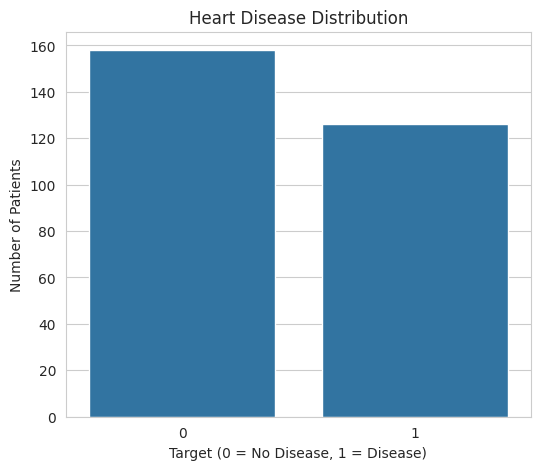

In [21]:
# STEP 3: CHECK TARGET CLASS DISTRIBUTION
# ============================================================

print("\n" + "="*60)
print("TARGET CLASS DISTRIBUTION")
print("="*60)

print(df['target'].value_counts())

plt.figure(figsize=(6,5))

sns.countplot(
    x='target',
    data=df
)

plt.title('Heart Disease Distribution')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Number of Patients')

plt.show()


Generating Correlation Heatmap...


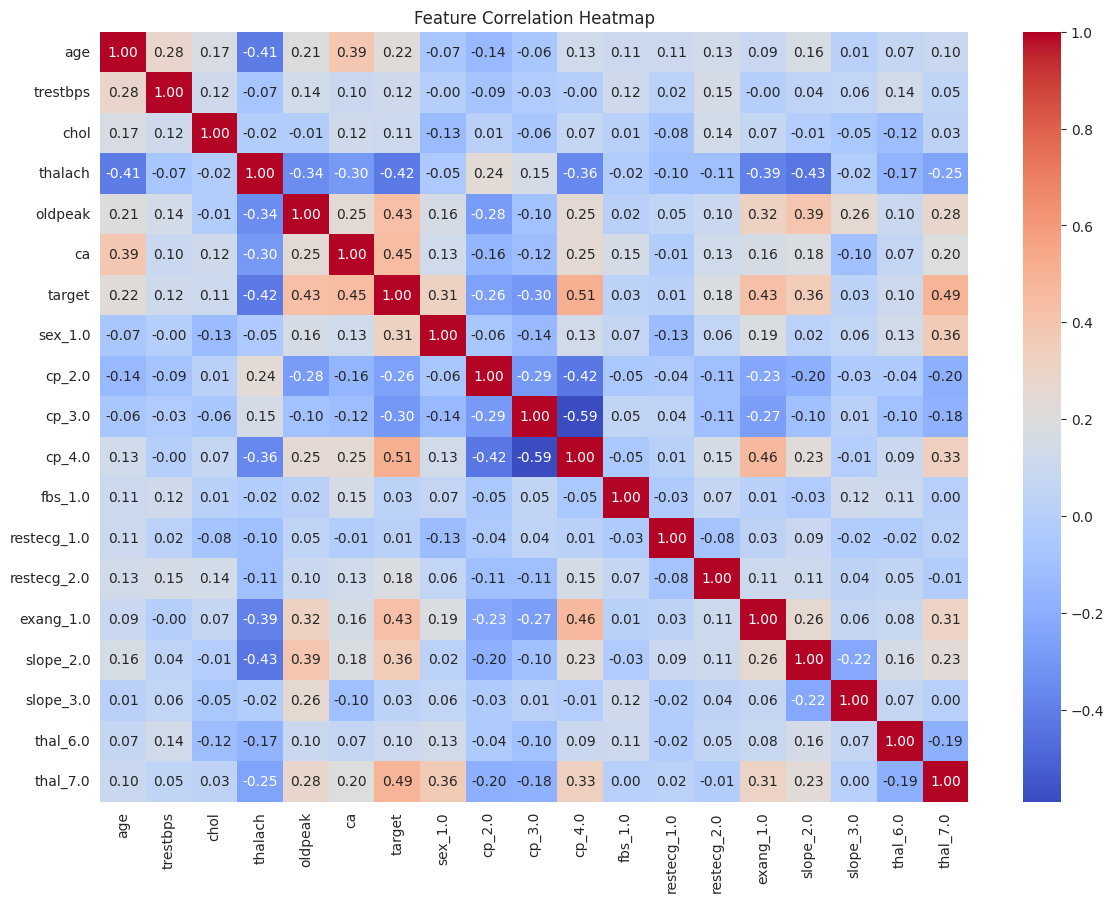

In [23]:
# STEP 4: CORRELATION HEATMAP
# ============================================================

print("\nGenerating Correlation Heatmap...")

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

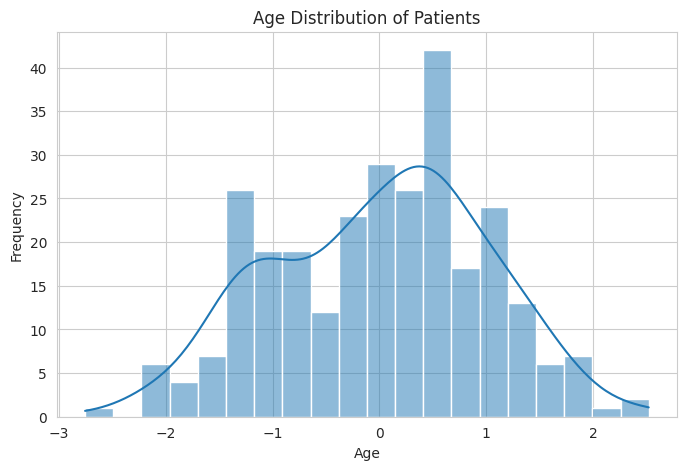

In [24]:
# STEP 5: AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True
)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()


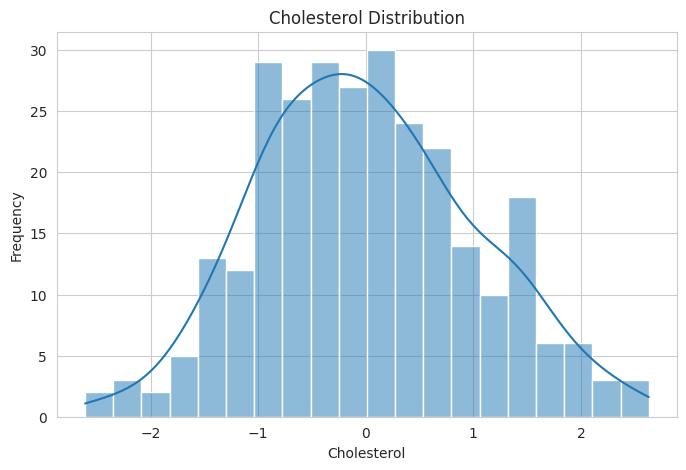

In [25]:
# STEP 6: CHOLESTEROL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['chol'],
    bins=20,
    kde=True
)

plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')

plt.show()

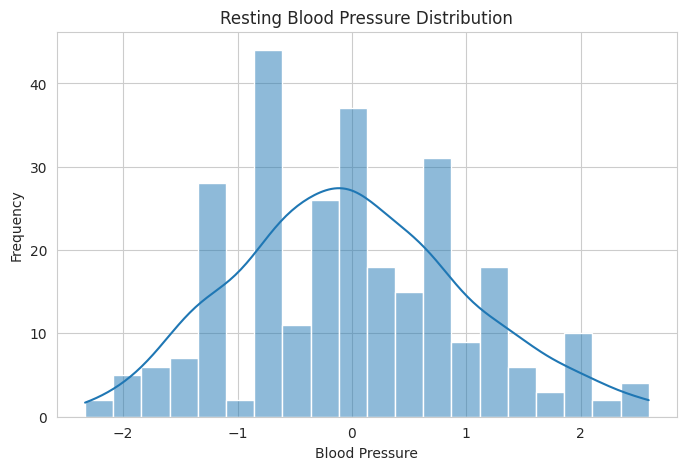

In [26]:
# STEP 7: RESTING BLOOD PRESSURE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['trestbps'],
    bins=20,
    kde=True
)

plt.title('Resting Blood Pressure Distribution')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')

plt.show()

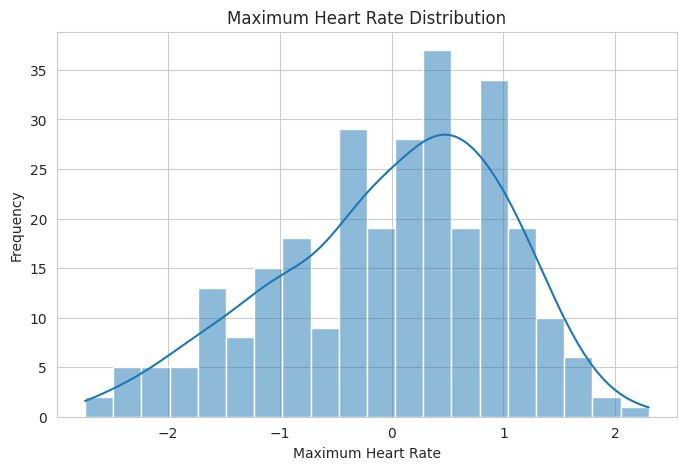

In [27]:
# STEP 8: MAXIMUM HEART RATE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['thalach'],
    bins=20,
    kde=True
)

plt.title('Maximum Heart Rate Distribution')
plt.xlabel('Maximum Heart Rate')
plt.ylabel('Frequency')

plt.show()

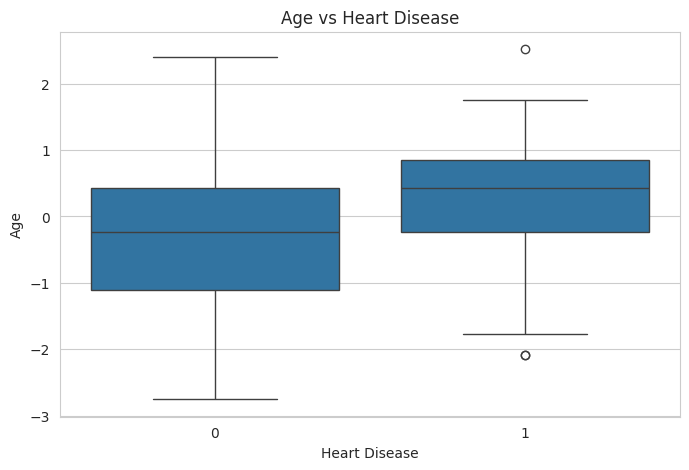

In [28]:
# STEP 9: AGE VS HEART DISEASE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='age',
    data=df
)

plt.title('Age vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Age')

plt.show()

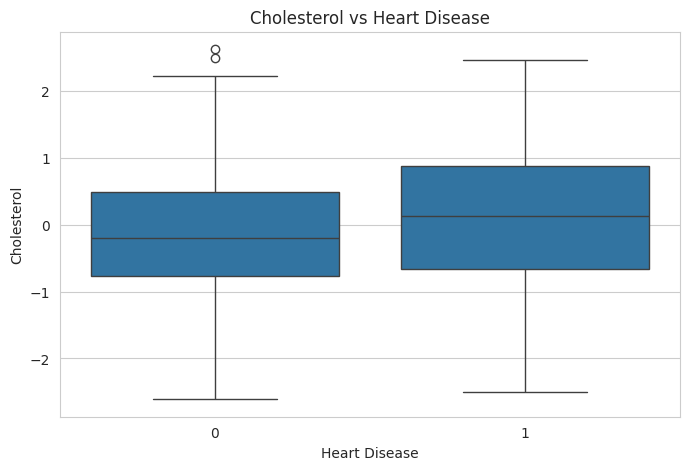

In [29]:
# STEP 10: CHOLESTEROL VS HEART DISEASE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='chol',
    data=df
)

plt.title('Cholesterol vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Cholesterol')

plt.show()

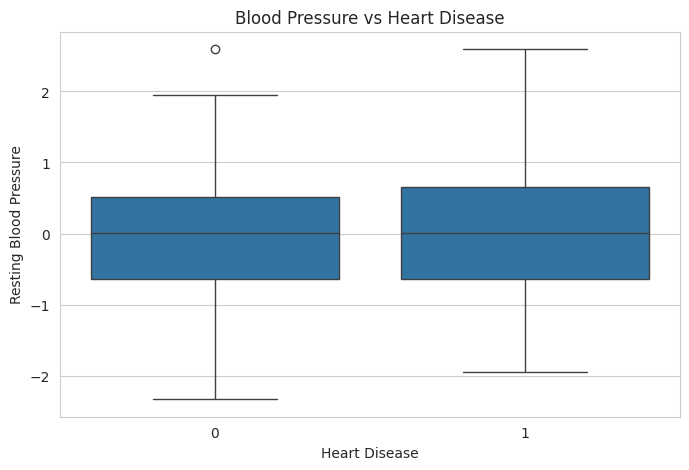

In [30]:
# STEP 11: BLOOD PRESSURE VS HEART DISEASE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='trestbps',
    data=df
)

plt.title('Blood Pressure vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Resting Blood Pressure')

plt.show()

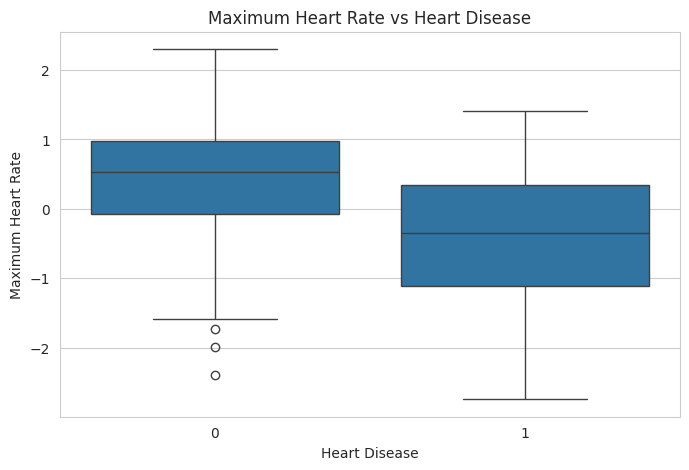

In [31]:
# STEP 12: HEART RATE VS HEART DISEASE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='thalach',
    data=df
)

plt.title('Maximum Heart Rate vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Maximum Heart Rate')

plt.show()


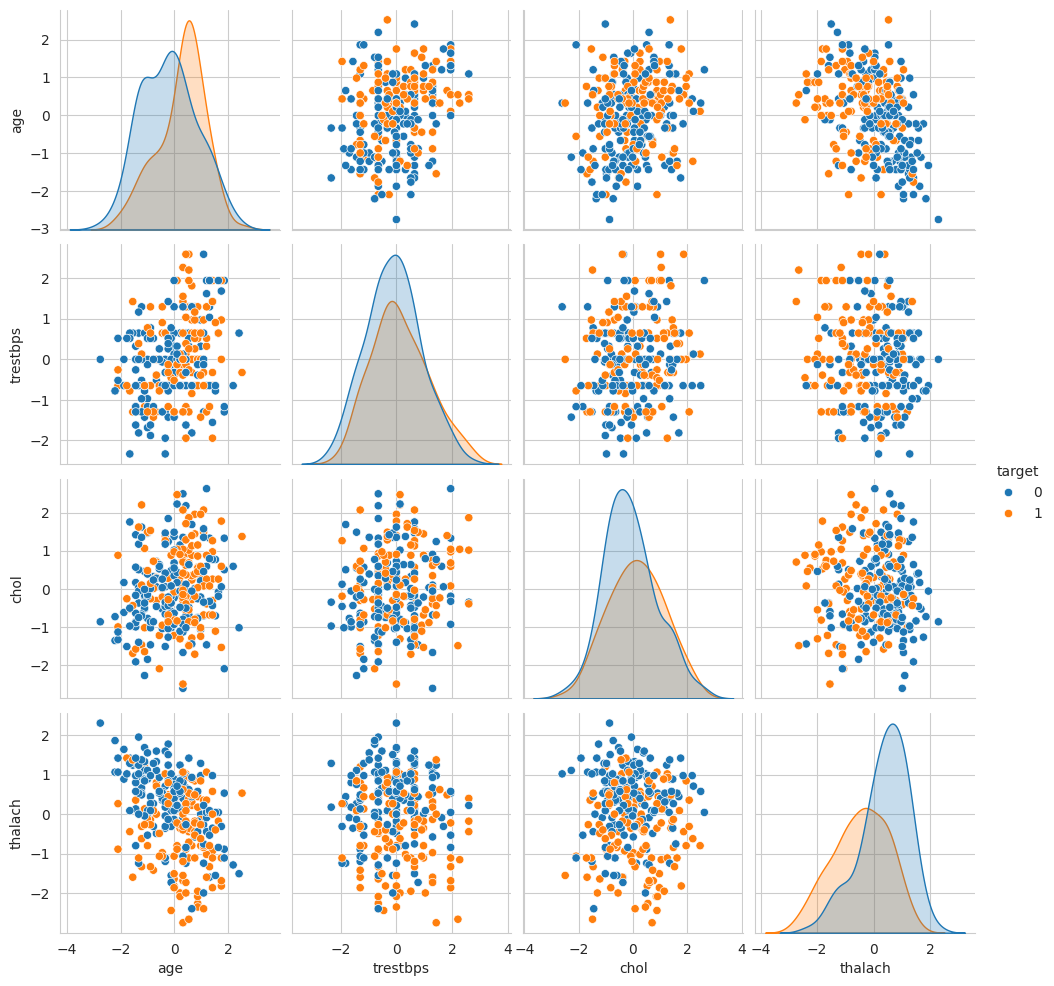

In [32]:
# STEP 13: PAIRPLOT OF IMPORTANT FEATURES
# ============================================================

important_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'target'
]

sns.pairplot(
    df[important_features],
    hue='target'
)

plt.show()

In [33]:
# STEP 14: FEATURES MOST CORRELATED WITH TARGET
# ============================================================

print("\n" + "="*60)
print("FEATURES CORRELATED WITH HEART DISEASE")
print("="*60)

correlation_target = df.corr()['target']

correlation_target = correlation_target.sort_values(
    ascending=False
)

print(correlation_target)



FEATURES CORRELATED WITH HEART DISEASE
target         1.000000
cp_4.0         0.510128
thal_7.0       0.490604
ca             0.452782
oldpeak        0.428824
exang_1.0      0.427594
slope_2.0      0.360250
sex_1.0        0.310888
age            0.224333
restecg_2.0    0.181150
trestbps       0.121871
chol           0.110564
thal_6.0       0.103304
slope_3.0      0.027708
fbs_1.0        0.025539
restecg_1.0    0.009550
cp_2.0        -0.257716
cp_3.0        -0.303097
thalach       -0.419522
Name: target, dtype: float64


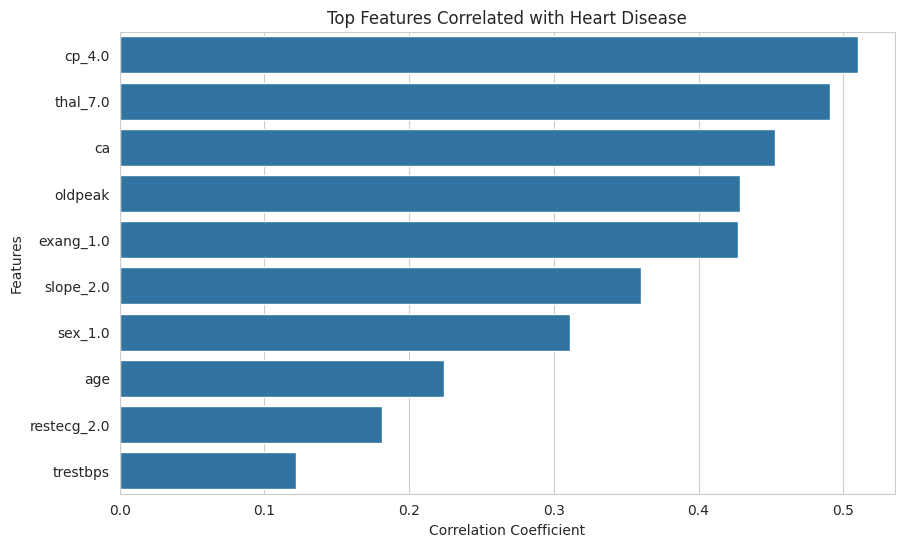

In [34]:
# STEP 15: TOP 10 CORRELATED FEATURES VISUALIZATION
# ============================================================

top_features = correlation_target.drop('target')

top_features = top_features.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title('Top Features Correlated with Heart Disease')

plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.show()

In [35]:
# EDA COMPLETED
# ============================================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS COMPLETED")
print("="*60)


EXPLORATORY DATA ANALYSIS COMPLETED


In [36]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Features and Target

X = df.drop('target', axis=1)
y = df['target']

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

Training Set Shape : (227, 18)
Testing Set Shape  : (57, 18)


In [37]:
# ============================================================
# MODEL BUILDING
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

# Support Vector Machine
svm = SVC(
    probability=True,
    random_state=42
)
svm.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [38]:
# ============================================================
# MODEL PREDICTIONS
# ============================================================

y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_svm = svm.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [39]:
# ============================================================
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("\n" + "="*50)
    print(model_name)
    print("="*50)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("SVM", y_test, y_pred_svm)


Logistic Regression
Accuracy  : 0.8772
Precision : 0.8750
Recall    : 0.8400
F1 Score  : 0.8571

Decision Tree
Accuracy  : 0.7018
Precision : 0.6667
Recall    : 0.6400
F1 Score  : 0.6531

Random Forest
Accuracy  : 0.7719
Precision : 0.7308
Recall    : 0.7600
F1 Score  : 0.7451

SVM
Accuracy  : 0.7368
Precision : 0.7273
Recall    : 0.6400
F1 Score  : 0.6809


In [40]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

results = []

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for name, prediction in models.items():

    results.append([
        name,
        accuracy_score(y_test, prediction),
        precision_score(y_test, prediction),
        recall_score(y_test, prediction),
        f1_score(y_test, prediction)
    ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(comparison_df)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression  0.877193   0.875000    0.84  0.857143
2        Random Forest  0.771930   0.730769    0.76  0.745098
3                  SVM  0.736842   0.727273    0.64  0.680851
1        Decision Tree  0.701754   0.666667    0.64  0.653061


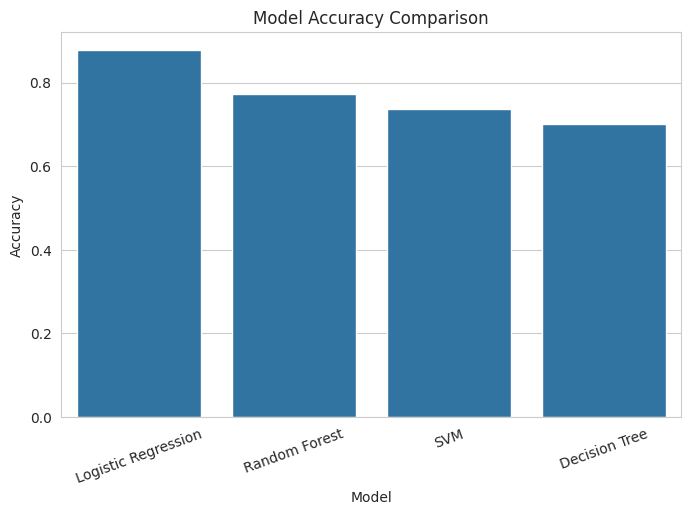

In [41]:
# ============================================================
# ACCURACY COMPARISON CHART
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')

plt.xticks(rotation=20)

plt.show()

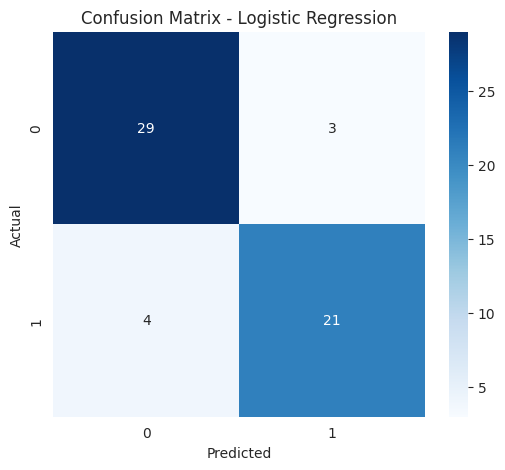

In [42]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        32
           1       0.88      0.84      0.86        25

    accuracy                           0.88        57
   macro avg       0.88      0.87      0.87        57
weighted avg       0.88      0.88      0.88        57



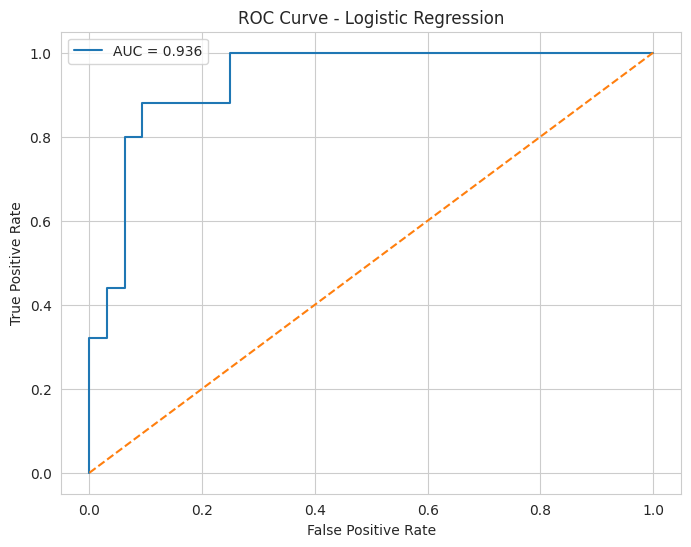

AUC Score: 0.93625


In [44]:
# ============================================================
# ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve, auc

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Logistic Regression')

plt.legend()

plt.show()

print("AUC Score:", roc_auc)

        Feature  Coefficient  Absolute_Value
9        cp_4.0     1.482734        1.482734
17     thal_7.0     1.418712        1.418712
6       sex_1.0     1.010712        1.010712
5            ca     0.910164        0.910164
13    exang_1.0     0.668791        0.668791
14    slope_2.0     0.582860        0.582860
4       oldpeak     0.409839        0.409839
15    slope_3.0     0.404635        0.404635
3       thalach    -0.396101        0.396101
12  restecg_2.0     0.381207        0.381207


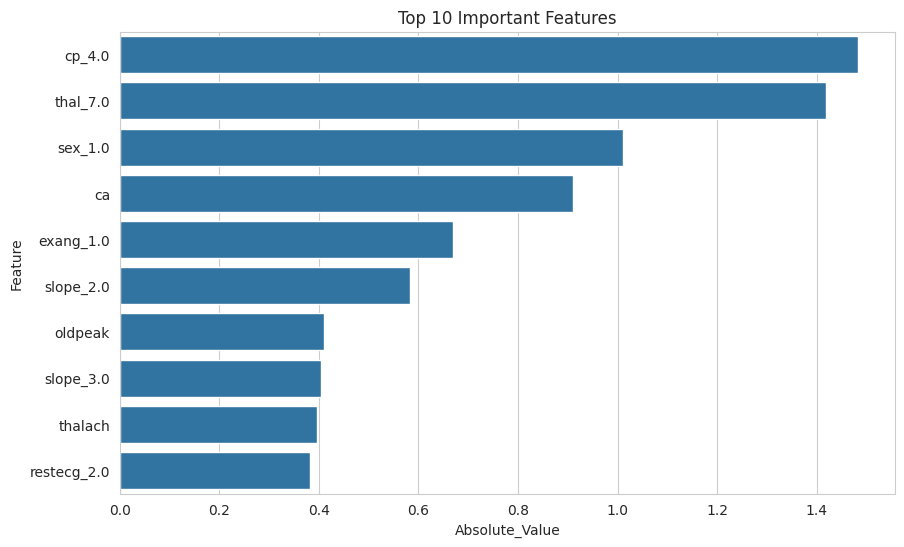

In [45]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

feature_importance['Absolute_Value'] = abs(
    feature_importance['Coefficient']
)

feature_importance = feature_importance.sort_values(
    by='Absolute_Value',
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Absolute_Value',
    y='Feature'
)

plt.title('Top 10 Important Features')

plt.show()

In [46]:
df.to_csv("heart_disease_preprocessed.csv", index=False)

In [47]:
from google.colab import files
files.download("heart_disease_preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
results = X_test.copy()

results['Actual'] = y_test.values
results['Predicted'] = y_pred_lr

results.to_csv(
    "heart_disease_predictions.csv",
    index=False
)